# Universidad Autónoma de Aguascalientes
## Centro de Ciencias Básicas — Departamento de Ciencias de la Computación
## Academia de Inteligencia Artificial

---

| Campo | Dato |
|---|---|
| **Materia** | Machine Learning — Deep Learning |
| **Profesor** | Dr. Francisco Javier Luna Rosas |
| **Carrera** | Ingeniería en Computación Inteligente |
| **Semestre** | 10° — Periodo Enero–Junio 2026 |
| **Tipo** | Proyecto Etapa 4 |
| **Alumno** | Carlos Daniel Torres Macías |
| **Fecha** | 27 Mayo 2026 |

---

# Sistema de Reconocimiento Facial en Tiempo Real
## Pipeline: MTCNN → FaceNet (VGGFace2) → SVM Calibrado

> **Objetivo:** Implementar un sistema de reconocimiento facial capaz de determinar en tiempo real si la persona frente a la cámara soy yo *Daniel* o una persona desconocida, usando detección con MTCNN, extracción de características con FaceNet y clasificación con SVM.

---
# 1. Introducción al Reconocimiento Facial

El **reconocimiento facial** es una tarea de visión por computadora que consiste en identificar o verificar la identidad de una persona a partir de su rostro. Se distinguen dos sub-tareas principales:

- **Verificación (1:1):** ¿Esta cara es la de la persona X? (lo que implementamos aquí)
- **Identificación (1:N):** ¿A quién de estas N personas pertenece esta cara?

## 1.1 Pipeline clásico de reconocimiento facial

```
Imagen/Frame  →  Detección  →  Alineación  →  Extracción  →  Clasificación
               (MTCNN)        (landmarks)     (FaceNet)       (SVM / umbral)
```

## 1.2 Evolución histórica

| Año | Método | Característica |
|---|---|---|
| 1991 | Eigenfaces (PCA) | Proyección lineal del espacio de píxeles |
| 2001 | Viola-Jones | Cascadas Haar para detección en tiempo real |
| 2014 | DeepFace (Facebook) | CNN profunda, 97.35% en LFW |
| 2015 | FaceNet (Google) | Embeddings de 128/512 dims + Triplet Loss, 99.63% en LFW |
| 2018 | ArcFace | Margin angular, estado del arte actual |
| 2019+ | MTCNN + modelos preentrenados | Pipeline industrial estándar |

## 1.3 Justificación del enfoque elegido

Se eligió **MTCNN + FaceNet (VGGFace2) + SVM** por las siguientes razones:

- **MTCNN** detecta y alinea caras con alta precisión incluso en condiciones variables de iluminación y pose, utilizando tres redes CNN en cascada (P-Net, R-Net, O-Net).
- **FaceNet preentrenado** en VGGFace2 (3.31M imágenes, 9,131 personas) extrae vectores de 512 dimensiones que codifican la identidad facial de forma robusta — sin necesidad de reentrenarlo.
- **SVM con kernel RBF** en el espacio de embeddings es un clasificador muy efectivo para separar distribuciones en alta dimensión con pocos ejemplos de entrenamiento (300 fotos es más que suficiente).
- Este es el mismo enfoque utilizado en producción por sistemas de control de acceso y dispositivos móviles.

---
# 2. Análisis de Arquitecturas

## 2.1 MTCNN — Multi-task Cascaded Convolutional Networks

Propuesta por Zhang et al. (2016), MTCNN es un pipeline de tres CNNs en cascada que resuelve simultáneamente detección de caras y localización de puntos clave (landmarks):

| Red | Entrada | Función | Salida |
|---|---|---|---|
| **P-Net** (Proposal) | Imagen completa (pirámide de escalas) | Propone regiones candidatas | ~thousands de bounding boxes |
| **R-Net** (Refine) | Parches 24×24 de candidatos | Filtra falsos positivos | Decenas de boxes refinados |
| **O-Net** (Output) | Parches 48×48 de candidatos | Clasificación final + landmarks | Boxes finales + 5 puntos faciales |

Los 5 landmarks (ojos izq/der, nariz, boca izq/der) permiten **alinear** la cara antes de extraer el embedding, lo que mejora la robustez del reconocimiento.

## 2.2 FaceNet — InceptionResNet-V1

FaceNet usa una arquitectura **Inception-ResNet-V1** para mapear imágenes de caras a un espacio euclidiano de 512 dimensiones donde:
- Caras de la **misma persona** → vectores muy cercanos (distancia pequeña)
- Caras de **personas distintas** → vectores alejados (distancia grande)

Fue entrenada con **Triplet Loss**: para un ancla `a`, un ejemplo positivo `p` (misma persona) y uno negativo `n` (distinta persona):

$$\mathcal{L} = \sum_i \left[ \|f(a_i) - f(p_i)\|^2 - \|f(a_i) - f(n_i)\|^2 + \alpha \right]_+$$

Usamos los pesos preentrenados en **VGGFace2** (disponibles en `facenet-pytorch`), que incluyen mayor diversidad étnica y de pose que el dataset original de Google.

## 2.3 SVM con kernel RBF

El **Support Vector Machine** busca el hiperplano de máximo margen que separa las clases en el espacio de embeddings de 512 dimensiones. El kernel RBF (Radial Basis Function) permite separaciones no lineales:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

Se usa **GridSearchCV** para optimizar los hiperparámetros `C` (margen vs. error) y `γ` (ancho del kernel). La calibración con **Platt scaling** permite obtener probabilidades calibradas en lugar de solo la clase predicha.

## 2.4 Dataset de clases negativas — LFW

**Labeled Faces in the Wild (LFW)** es un benchmark estándar con 13,233 imágenes de 5,749 personas diferentes, disponible directamente en `scikit-learn`. Se usa como clase negativa ("No es Daniel") para entrenar el clasificador binario.

---
# 3. Implementación
## 3.1 Instalación y configuración

In [1]:
# ============================================================
# CELDA 1: Instalación de dependencias
# EJECUTAR SOLO UNA VEZ — luego reiniciar el runtime
# ============================================================
import importlib, sys

# Verificar si ya está instalado (post-reinicio)
try:
    from facenet_pytorch import MTCNN, InceptionResnetV1
    import torch
    print(f'Todo listo. PyTorch: {torch.__version__}')
    print(f'   CUDA: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print('\nPuedes continuar con la Celda 2.')

except ImportError:
    print('Instalando dependencias...')
    !pip install facenet-pytorch torch torchvision \
                 scikit-learn matplotlib seaborn pillow \
                 opencv-python-headless tqdm --quiet

    print()
    print('=' * 55)
    print('Instalación completada.')
    print()
    print('REINICIA EL RUNTIME AHORA:')
    print('    Menú → Runtime → Restart session')
    print('    (o el atajo Ctrl + M  luego  .')
    print()
    print('    Después vuelve a ejecutar ESTA misma celda.')
    print('    Si muestra "Todo listo", ya puedes ir a Celda 2.')
    print('=' * 55)

Todo listo. PyTorch: 2.2.2+cu121
   CUDA: True
   GPU : NVIDIA A100-SXM4-40GB

Puedes continuar con la Celda 2.


In [2]:
# ============================================================
# CELDA 2: Imports
# ============================================================
import os, io, json, time, pickle, base64, shutil, zipfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from facenet_pytorch import MTCNN, InceptionResnetV1

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.datasets import fetch_lfw_people

from google.colab import files
from google.colab.output import eval_js

warnings.filterwarnings('ignore')

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

# Semilla
np.random.seed(42)
torch.manual_seed(42)

Dispositivo: cuda


In [3]:
# ============================================================
# CELDA 3: Hiperparámetros y constantes
# ============================================================

# ─── Pipeline ────────────────────────────────────────────────
IMG_SIZE         = 160        # FaceNet espera 160×160
MARGIN           = 20         # Pixels de margen al recortar cara
MIN_FACE_PROB    = 0.90       # Confianza mínima de MTCNN
EMBEDDING_DIM    = 512        # Dimensión del vector FaceNet

# ─── Clases ─────────────────────────────────────────────────
DANIEL_LABEL     = 1
OTHER_LABEL      = 0
DANIEL_NAME      = 'Daniel'   # ← Cambia si es otro nombre

# ─── Dataset ─────────────────────────────────────────────────
MAX_OTHER_FACES  = 400        # Caras LFW para clase negativa
TEST_SIZE        = 0.20       # 80% entrenamiento / 20% prueba

# ─── SVM ────────────────────────────────────────────────────
SVM_PARAM_GRID   = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}
CV_FOLDS         = 5

# ─── Rutas ──────────────────────────────────────────────────
DATA_DIR         = '/content/dataset_daniel'
RESULTS_DIR      = '/content/resultados_fase4'
MODEL_DIR        = '/content/modelos'
SVM_PATH         = f'{MODEL_DIR}/svm_model.pkl'
RESNET_PATH      = f'{MODEL_DIR}/facenet_weights.pth'

for d in [DATA_DIR, RESULTS_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print('Configuración cargada.')
print(f'  Clase positiva : {DANIEL_NAME} (label={DANIEL_LABEL})')
print(f'  Clase negativa : Otras personas (label={OTHER_LABEL})')
print(f'  Max otras caras: {MAX_OTHER_FACES}')

Configuración cargada.
  Clase positiva : Daniel (label=1)
  Clase negativa : Otras personas (label=0)
  Max otras caras: 400


---
## 3.2 Cargar modelos MTCNN y FaceNet

In [4]:
# ============================================================
# CELDA 4: Inicializar MTCNN y FaceNet (pesos preentrenados)
# ============================================================
print('Cargando MTCNN...')
mtcnn = MTCNN(
    image_size=IMG_SIZE,
    margin=MARGIN,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],  # P-Net, R-Net, O-Net
    factor=0.709,
    post_process=True,            # Normaliza a [-1, 1] para FaceNet
    keep_all=True,                # Devuelve todas las caras detectadas
    device=DEVICE
)

print('Cargando FaceNet (InceptionResNetV1 preentrenado en VGGFace2)...')
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)

# Congelar pesos — solo lo usamos como extractor de características
for param in resnet.parameters():
    param.requires_grad = False

params = sum(p.numel() for p in resnet.parameters())
print(f'FaceNet cargado: {params:,} parámetros (todos congelados)')
print('MTCNN y FaceNet listos.')

Cargando MTCNN...
Cargando FaceNet (InceptionResNetV1 preentrenado en VGGFace2)...


  0%|          | 0.00/107M [00:00<?, ?B/s]

FaceNet cargado: 27,910,327 parámetros (todos congelados)
MTCNN y FaceNet listos.


In [5]:
import cv2
import numpy as np
import torch
from PIL import Image

# ============================================================
# CELDA 4B: Detector de caras con OpenCV (reemplaza MTCNN)
# ============================================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detectar_cara_opencv(img_pil):
    """
    Detecta la cara más grande en una imagen PIL.
    Devuelve el recorte de cara como PIL Image, o None si no detecta.
    """
    img_np   = np.array(img_pil.convert('RGB'))
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Escalar a máx 1000px para imágenes grandes
    scale = min(1.0, 1000 / max(img_np.shape[:2]))
    if scale < 1.0:
        h, w     = img_np.shape[:2]
        img_np   = cv2.resize(img_np,   (int(w*scale), int(h*scale)))
        img_gray = cv2.resize(img_gray, (int(w*scale), int(h*scale)))

    caras = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(40, 40)
    )

    if len(caras) == 0:
        # Fallback: recorte central cuadrado
        h, w   = img_np.shape[:2]
        lado   = min(w, h)
        cx, cy = w // 2, h // 2
        x1, y1 = cx - lado//2, cy - lado//2
        crop   = img_np[max(0,y1):y1+lado, max(0,x1):x1+lado]
    else:
        # Cara más grande detectada
        x, y, w, h = max(caras, key=lambda r: r[2]*r[3])
        margen = int(max(w, h) * 0.25)
        x1 = max(0, x - margen)
        y1 = max(0, y - margen)
        x2 = min(img_np.shape[1], x + w + margen)
        y2 = min(img_np.shape[0], y + h + margen)
        crop = img_np[y1:y2, x1:x2]

    if crop.size == 0:
        return None, None

    # Devolver también las coordenadas escaladas de vuelta
    box = (x1, y1, x1 + crop.shape[1], y1 + crop.shape[0]) if len(caras) > 0 else None
    return Image.fromarray(crop), box


def extraer_embedding(img_pil):
    """Detecta cara con OpenCV y extrae embedding FaceNet."""
    cara_pil, _ = detectar_cara_opencv(img_pil)
    if cara_pil is None:
        return None

    cara_resized = cara_pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    face_tensor  = torch.tensor(
        np.array(cara_resized).transpose(2, 0, 1).astype(np.float32)
    ).unsqueeze(0)
    face_tensor  = (face_tensor / 127.5) - 1.0

    with torch.no_grad():
        emb = resnet(face_tensor.to(DEVICE))

    return emb.cpu().numpy()[0]

# Test rápido con verificación de existencia de variables
if 'daniel_paths' in globals() and len(daniel_paths) > 0:
    img_test = Image.open(daniel_paths[0])
    cara, box = detectar_cara_opencv(img_test)
    if cara:
        print(f"✅ OpenCV detectó cara: {cara.size}")
        cara.resize((160,160)).save(f'{RESULTS_DIR}/cara_test.jpg')
        print(f"   Guardada en {RESULTS_DIR}/cara_test.jpg")
    else:
        print("❌ No detectó cara ni con fallback")
else:
    print("ℹ️ Para probar esta celda, primero debes ejecutar la CELDA 5 para cargar 'daniel_paths'.")

ℹ️ Para probar esta celda, primero debes ejecutar la CELDA 5 para cargar 'daniel_paths'.


---
## 3.3 Preparar Dataset

> Sube el mismo ZIP de fotos que usaste en Fase 3. Se reutiliza directamente.

In [6]:
# ============================================================
# CELDA 5: Cargar dataset desde Google Drive
# ============================================================
from google.colab import drive
import zipfile, shutil, os

# Montar Drive (abre un popup de autorización la primera vez)
drive.mount('/content/drive')

# ── Ajusta esta ruta con el nombre real de tu ZIP ──────────
ZIP_EN_DRIVE = '/content/drive/MyDrive/fotos_daniel.zip'
# ──────────────────────────────────────────────────────────

os.makedirs(DATA_DIR, exist_ok=True)

print('Extrayendo ZIP...')
with zipfile.ZipFile(ZIP_EN_DRIVE, 'r') as z:
    z.extractall('/content/tmp_daniel/')

img_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
daniel_paths = []
for root, _, files_list in os.walk('/content/tmp_daniel/'):
    for f in files_list:
        if f.lower().endswith(img_ext):
            src = os.path.join(root, f)
            dst = os.path.join(DATA_DIR, f)
            shutil.copy2(src, dst)
            daniel_paths.append(dst)

print(f'✅ {len(daniel_paths)} fotos cargadas desde Drive')

Mounted at /content/drive
Extrayendo ZIP...
✅ 521 fotos cargadas desde Drive


In [7]:
# ============================================================
# CELDA 6: Función principal — extraer embedding de una imagen
# ============================================================

def extraer_embedding(img_pil):
    img_rgb = img_pil.convert('RGB')
    w, h    = img_rgb.size

    # Estrategias de preprocesamiento en orden de agresividad
    candidatos = []

    # 1. Resize suave a 1000px
    ratio = 1000 / max(w, h)
    candidatos.append(img_rgb.resize((int(w*ratio), int(h*ratio)), Image.LANCZOS))

    # 2. Resize más pequeño a 600px (a veces funciona mejor)
    ratio2 = 600 / max(w, h)
    candidatos.append(img_rgb.resize((int(w*ratio2), int(h*ratio2)), Image.LANCZOS))

    # 3. Recorte central 60% de la imagen (si la cara está al centro)
    cx, cy  = w // 2, h // 2
    cw, ch  = int(w * 0.6), int(h * 0.6)
    cropped = img_rgb.crop((cx-cw//2, cy-ch//2, cx+cw//2, cy+ch//2))
    ratio3  = 800 / max(cropped.size)
    candidatos.append(cropped.resize(
        (int(cropped.width*ratio3), int(cropped.height*ratio3)), Image.LANCZOS
    ))

    for img_try in candidatos:
        faces, probs = mtcnn(img_try, return_prob=True)
        if faces is None:
            continue

        if len(faces.shape) == 4:
            best_idx = int(np.argmax(probs))
            if probs[best_idx] < 0.30:   # umbral muy permisivo
                continue
            face_tensor = faces[best_idx].unsqueeze(0)
        else:
            if probs[0] < 0.30:
                continue
            face_tensor = faces.unsqueeze(0)

        with torch.no_grad():
            emb = resnet(face_tensor.to(DEVICE))
        return emb.cpu().numpy()[0]

    return None  # Las 3 estrategias fallaron

# Test rápido con la primera foto
if daniel_paths:
    img_test = Image.open(daniel_paths[0])
    emb_test = extraer_embedding(img_test)
    if emb_test is not None:
        print(f'Extracción de embedding OK: shape={emb_test.shape}, norma={np.linalg.norm(emb_test):.4f}')
    else:
        print('No se detectó cara en la primera imagen. Verifica las fotos.')

Extracción de embedding OK: shape=(512,), norma=1.0000


In [10]:
import time, base64, io, os
from PIL import Image
from google.colab.output import eval_js

# ============================================================
# CAPTURA DE FRAMES WEBCAM PARA MEJORAR EL ENTRENAMIENTO
# ============================================================
N_FRAMES_CAPTURAR = 80   # Capturaremos 80 variaciones

eval_js('''
(async () => {
  if (window._webcamStream) return "ya activa";
  window._webcamStream = await navigator.mediaDevices.getUserMedia(
    {video:{width:{ideal:640},height:{ideal:480},facingMode:"user"}}
  );
  const v = document.createElement("video");
  v.id = "cap-video"; v.muted = true;
  v.setAttribute("playsinline","");
  v.style.cssText = "width:360px;border-radius:8px;display:block;margin:10px auto;transform:scaleX(-1)";
  v.srcObject = window._webcamStream;
  document.body.prepend(v);
  await v.play();
  google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
})()
''')

time.sleep(2)
print(f"Capturando {N_FRAMES_CAPTURAR} frames — muévete un poco (gira la cabeza, sonríe, aléjate/acércate)")

webcam_paths = []
existentes = len([f for f in os.listdir(DATA_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])

for i in range(N_FRAMES_CAPTURAR):
    frame_b64 = eval_js('''
    (() => {
      const v = document.getElementById("cap-video");
      if (!v || !v.videoWidth) return "null";
      const c = document.createElement("canvas");
      c.width = v.videoWidth; c.height = v.videoHeight;
      c.getContext("2d").drawImage(v, 0, 0);
      return c.toDataURL("image/jpeg", 0.92);
    })()
    ''')

    if frame_b64 and frame_b64 != 'null':
        img_bytes = base64.b64decode(frame_b64.split(',')[1])
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        ruta = os.path.join(DATA_DIR, f'webcam_{existentes+i:04d}.jpg')
        img.save(ruta, 'JPEG', quality=95)
        webcam_paths.append(ruta)
        # Actualizar lista de rutas global para que la Celda 7 las vea
        if ruta not in daniel_paths: daniel_paths.append(ruta)

    time.sleep(0.3)

print(f"✅ {len(webcam_paths)} frames guardados en {DATA_DIR}")
print("IMPORTANTE: Ahora re-ejecuta desde la CELDA 7 para incluir estas imágenes en el entrenamiento.")

Capturando 80 frames — muévete un poco (gira la cabeza, sonríe, aléjate/acércate)
✅ 80 frames guardados en /content/dataset_daniel
IMPORTANTE: Ahora re-ejecuta desde la CELDA 7 para incluir estas imágenes en el entrenamiento.


In [11]:
# ============================================================
# CELDA 7: Extraer embeddings de las fotos de Daniel
# ============================================================
print(f'Extrayendo embeddings de {len(daniel_paths)} fotos de {DANIEL_NAME}...')

daniel_embeddings = []
daniel_failed = []

for path in tqdm(daniel_paths, desc=f'Procesando fotos de {DANIEL_NAME}'):
    try:
        img = Image.open(path)
        emb = extraer_embedding(img)
        if emb is not None:
            daniel_embeddings.append(emb)
        else:
            daniel_failed.append(path)
    except Exception as e:
        daniel_failed.append(path)

print(f'\nEmbeddings exitosos : {len(daniel_embeddings)}')
print(f'Sin cara detectada  : {len(daniel_failed)}')
print(f'   (Las imágenes sin cara se ignoran — son probablemente fotos muy oscuras o de perfil extremo)')

Extrayendo embeddings de 620 fotos de Daniel...


Procesando fotos de Daniel:   0%|          | 0/620 [00:00<?, ?it/s]


Embeddings exitosos : 423
Sin cara detectada  : 197
   (Las imágenes sin cara se ignoran — son probablemente fotos muy oscuras o de perfil extremo)


In [12]:
# ============================================================
# CELDA 8: Clase negativa — Dataset LFW (otras personas)
# ============================================================
print(f'Descargando LFW para clase negativa ("No es {DANIEL_NAME}")...')

lfw = fetch_lfw_people(
    min_faces_per_person=1,
    resize=1.0,
    color=True,        # RGB
    slice_=(slice(0, 250), slice(0, 250))  # Recorte cuadrado
)

# Barajar para diversidad
lfw_indices = np.random.permutation(len(lfw.images))[:MAX_OTHER_FACES]
lfw_sample  = lfw.images[lfw_indices]  # shape: (N, H, W, 3), valores 0-1

print(f'LFW descargado: {len(lfw.images)} imágenes totales')
print(f'Usando {len(lfw_sample)} imágenes para clase negativa')

# Extraer embeddings — LFW ya son caras recortadas, así que procesamos directamente
print('\nExtrayendo embeddings de LFW...')

other_embeddings = []

for img_arr in tqdm(lfw_sample, desc='Procesando LFW'):
    # Convertir a uint8 PIL
    img_pil = Image.fromarray((img_arr * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))

    # Intentar con MTCNN primero (puede que detecte mejor la cara)
    emb = extraer_embedding(img_pil)

    if emb is None:
        # LFW ya es cara recortada, procesar directamente con FaceNet
        img_tensor = torch.tensor(
            np.array(img_pil).transpose(2, 0, 1).astype(np.float32)
        ).unsqueeze(0)
        img_tensor = (img_tensor / 127.5) - 1.0  # Normalizar a [-1, 1]
        with torch.no_grad():
            emb = resnet(img_tensor.to(DEVICE)).cpu().numpy()[0]

    other_embeddings.append(emb)

print(f'\nEmbeddings LFW extraídos: {len(other_embeddings)}')

Descargando LFW para clase negativa ("No es Daniel")...
LFW descargado: 13233 imágenes totales
Usando 400 imágenes para clase negativa

Extrayendo embeddings de LFW...


Procesando LFW:   0%|          | 0/400 [00:00<?, ?it/s]


Embeddings LFW extraídos: 400


Dataset preparado:
  Total muestras    : 823
  Daniel          : 423  (51.4%)
  No Daniel       : 400  (48.6%)
  Entrenamiento     : 658
  Prueba            : 165
  Embedding dim     : 512


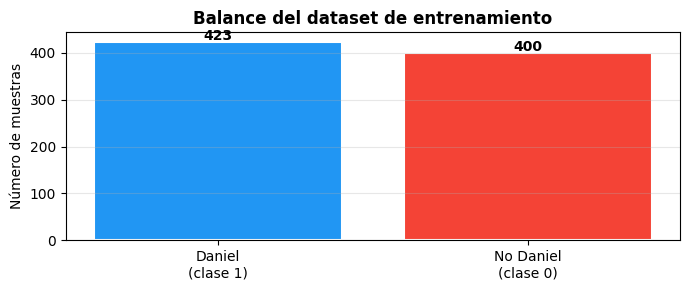

In [13]:
# ============================================================
# CELDA 9: Construir dataset y división train/test
# ============================================================

X_daniel = np.array(daniel_embeddings)  # (N_daniel, 512)
X_other  = np.array(other_embeddings)   # (N_other,  512)

y_daniel = np.ones(len(X_daniel),  dtype=int)   # 1 = Daniel
y_other  = np.zeros(len(X_other),  dtype=int)   # 0 = No Daniel

X = np.vstack([X_daniel, X_other])
y = np.concatenate([y_daniel, y_other])

# Normalizar embeddings (L2 norm) — recomendado para SVM
X = normalize(X, norm='l2')

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=42
)

print('Dataset preparado:')
print(f'  Total muestras    : {len(X)}')
print(f'  {DANIEL_NAME}          : {len(X_daniel)}  ({len(X_daniel)/len(X)*100:.1f}%)')
print(f'  No {DANIEL_NAME}       : {len(X_other)}  ({len(X_other)/len(X)*100:.1f}%)')
print(f'  Entrenamiento     : {len(X_train)}')
print(f'  Prueba            : {len(X_test)}')
print(f'  Embedding dim     : {X.shape[1]}')

# Visualizar distribución
fig, ax = plt.subplots(figsize=(7, 3))
labels_count = [len(X_daniel), len(X_other)]
bars = ax.bar([f'{DANIEL_NAME}\n(clase 1)', f'No {DANIEL_NAME}\n(clase 0)'],
              labels_count, color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, labels_count):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Balance del dataset de entrenamiento', fontweight='bold')
ax.set_ylabel('Número de muestras')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dataset_balance.png', dpi=150)
plt.show()

---
## 3.4 Entrenamiento del clasificador SVM

In [14]:
# ============================================================
# CELDA 10: Entrenamiento SVM con GridSearchCV
# ============================================================
print('Entrenando SVM con búsqueda de hiperparámetros (puede tomar 1-3 min)...')
print(f'Grid: C={SVM_PARAM_GRID["C"]}, gamma={SVM_PARAM_GRID["gamma"]}')
print(f'Cross-validation: {CV_FOLDS} folds estratificados\n')

t0 = time.time()

# SVM con probabilidad habilitada (Platt scaling) para outputs calibrados
svm_base = SVC(
    kernel='rbf',
    probability=True,          # Necesario para predict_proba
    class_weight='balanced',   # Maneja desbalance de clases automáticamente
    random_state=42
)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svm_base,
    SVM_PARAM_GRID,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

svm_model = grid_search.best_estimator_
elapsed = time.time() - t0

print(f'\nEntrenamiento completado en {elapsed:.1f}s')
print(f'Mejores hiperparámetros : {grid_search.best_params_}')
print(f'Mejor F1 (CV)           : {grid_search.best_score_:.4f}')

Entrenando SVM con búsqueda de hiperparámetros (puede tomar 1-3 min)...
Grid: C=[0.1, 1, 10, 100], gamma=['scale', 'auto', 0.001, 0.01]
Cross-validation: 5 folds estratificados

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Entrenamiento completado en 5.1s
Mejores hiperparámetros : {'C': 1, 'gamma': 'scale'}
Mejor F1 (CV)           : 1.0000


---
# 4. Evaluación del Modelo

       REPORTE DE EVALUACIÓN — SVM
  Accuracy (exactitud)  : 99.39%
  ROC-AUC               : 1.0000

              precision    recall  f1-score   support

   No Daniel       0.99      1.00      0.99        80
      Daniel       1.00      0.99      0.99        85

    accuracy                           0.99       165
   macro avg       0.99      0.99      0.99       165
weighted avg       0.99      0.99      0.99       165



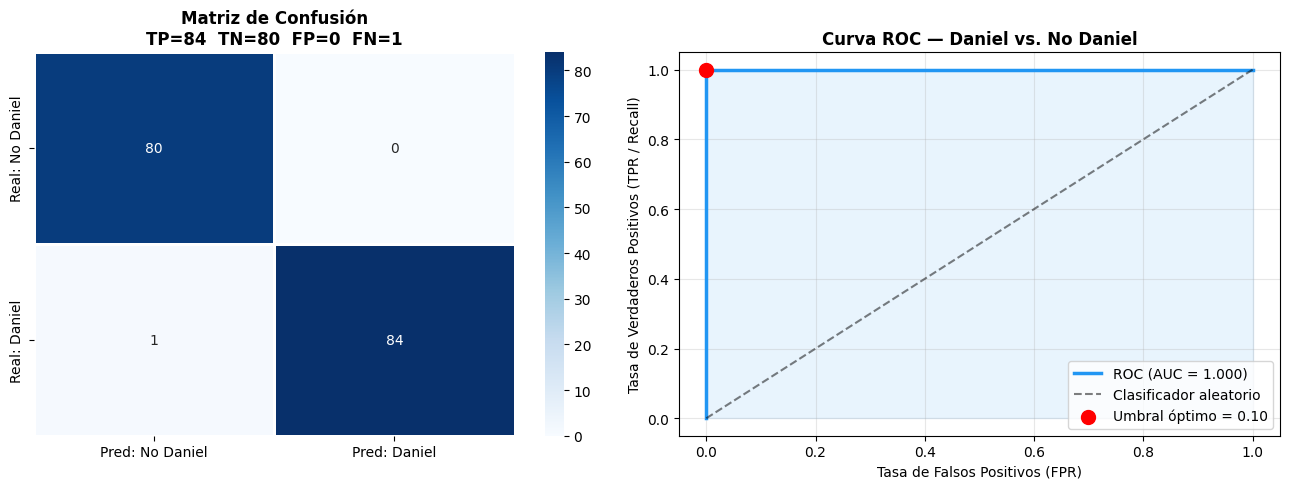


Umbral óptimo de decisión: 0.0996
(Se usará este valor en la inferencia en tiempo real)


In [15]:
# ============================================================
# CELDA 11: Métricas de evaluación completas
# ============================================================
y_pred  = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, DANIEL_LABEL]  # prob de ser Daniel

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print('=' * 55)
print(f'       REPORTE DE EVALUACIÓN — SVM')
print('=' * 55)
print(f'  Accuracy (exactitud)  : {acc*100:.2f}%')
print(f'  ROC-AUC               : {auc:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=[f'No {DANIEL_NAME}', DANIEL_NAME]
))

# ── Subplots: Matriz de Confusión + Curva ROC ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f'Pred: No {DANIEL_NAME}', f'Pred: {DANIEL_NAME}'],
    yticklabels=[f'Real: No {DANIEL_NAME}', f'Real: {DANIEL_NAME}'],
    ax=axes[0], linewidths=1
)
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'Matriz de Confusión\nTP={tp}  TN={tn}  FP={fp}  FN={fn}',
                  fontweight='bold')

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')

# Punto de operación óptimo (máximo F1)
f1_scores = 2 * tpr * (1-fpr) / (tpr + (1-fpr) + 1e-9)
opt_idx = np.argmax(f1_scores)
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
               label=f'Umbral óptimo = {thresholds[opt_idx]:.2f}')

axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[1].set_title(f'Curva ROC — {DANIEL_NAME} vs. No {DANIEL_NAME}', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/evaluacion_svm.png', dpi=150, bbox_inches='tight')
plt.show()

OPTIMAL_THRESHOLD = float(thresholds[opt_idx])
print(f'\nUmbral óptimo de decisión: {OPTIMAL_THRESHOLD:.4f}')
print('(Se usará este valor en la inferencia en tiempo real)')

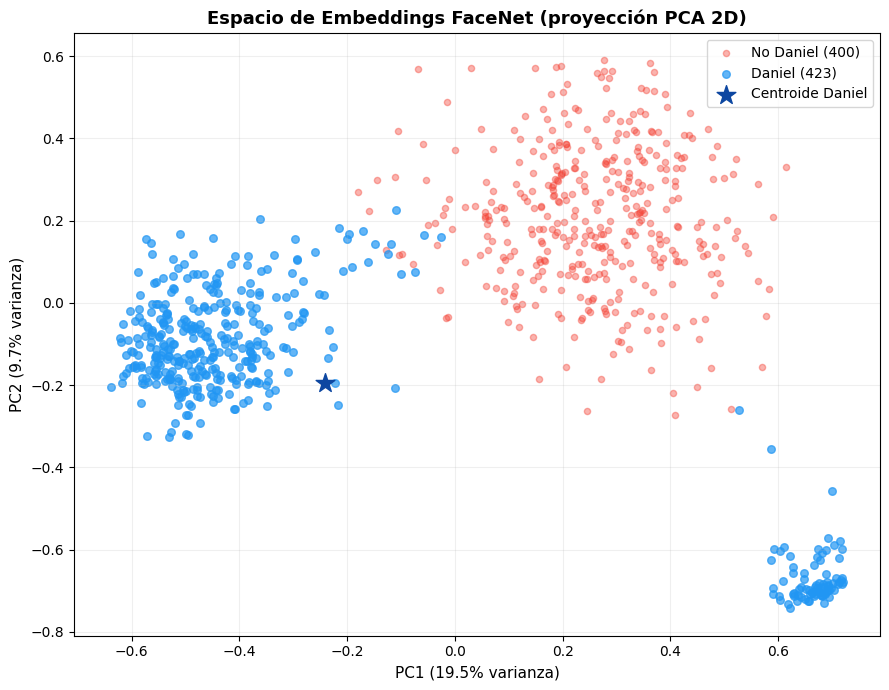

Visualización PCA guardada.


In [16]:
# ============================================================
# CELDA 12: Visualización del espacio de embeddings (PCA 2D)
# ============================================================
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))

mask_daniel = y == DANIEL_LABEL
mask_other  = y == OTHER_LABEL

ax.scatter(X_2d[mask_other, 0],  X_2d[mask_other, 1],
           c='#F44336', alpha=0.4, s=20, label=f'No {DANIEL_NAME} ({mask_other.sum()})')
ax.scatter(X_2d[mask_daniel, 0], X_2d[mask_daniel, 1],
           c='#2196F3', alpha=0.7, s=30, label=f'{DANIEL_NAME} ({mask_daniel.sum()})')

# Centroide de Daniel
centroid = X_2d[mask_daniel].mean(axis=0)
ax.scatter(*centroid, c='#0D47A1', s=200, marker='*',
           zorder=5, label=f'Centroide {DANIEL_NAME}')

var_expl = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var_expl[0]:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_expl[1]:.1f}% varianza)', fontsize=11)
ax.set_title('Espacio de Embeddings FaceNet (proyección PCA 2D)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embeddings_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualización PCA guardada.')

---
## 3.5 Guardar modelo

In [17]:
# ============================================================
# CELDA 13: Serializar y guardar modelos
# ============================================================

# Guardar SVM
with open(SVM_PATH, 'wb') as f:
    pickle.dump(svm_model, f)
print(f'SVM guardado en: {SVM_PATH}')

# Guardar pesos FaceNet (state dict)
torch.save(resnet.state_dict(), RESNET_PATH)
print(f'FaceNet guardado en: {RESNET_PATH}')

# Guardar metadata del modelo
metadata = {
    'daniel_name'      : DANIEL_NAME,
    'optimal_threshold': OPTIMAL_THRESHOLD,
    'img_size'         : IMG_SIZE,
    'embedding_dim'    : EMBEDDING_DIM,
    'min_face_prob'    : MIN_FACE_PROB,
    'best_svm_params'  : grid_search.best_params_,
    'accuracy'         : float(acc),
    'roc_auc'          : float(auc),
    'n_daniel_train'   : int(mask_daniel.sum()),
    'n_other_train'    : int(mask_other.sum()),
    'daniel_label'     : DANIEL_LABEL,
    'other_label'      : OTHER_LABEL,
}
with open(f'{MODEL_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata guardada en: {MODEL_DIR}/model_metadata.json')
print(f'\nResumen del modelo:')
for k, v in metadata.items():
    print(f'  {k:25s}: {v}')

SVM guardado en: /content/modelos/svm_model.pkl
FaceNet guardado en: /content/modelos/facenet_weights.pth
Metadata guardada en: /content/modelos/model_metadata.json

Resumen del modelo:
  daniel_name              : Daniel
  optimal_threshold        : 0.09959292453631505
  img_size                 : 160
  embedding_dim            : 512
  min_face_prob            : 0.9
  best_svm_params          : {'C': 1, 'gamma': 'scale'}
  accuracy                 : 0.9939393939393939
  roc_auc                  : 1.0
  n_daniel_train           : 423
  n_other_train            : 400
  daniel_label             : 1
  other_label              : 0


---
# 5. Demo en Tiempo Real — Google Colab

El siguiente widget captura frames desde la cámara web, los envía a Python para inferencia, y muestra el resultado con bounding box y etiqueta directamente en el navegador.

In [19]:
# ── Diagnóstico MTCNN ──────────────────────────────────────────
from PIL import Image
import numpy as np

img_test = Image.open(daniel_paths[0]).convert('RGB')
print(f"Tamaño foto: {img_test.size}")

# Ver qué detecta realmente MTCNN sin filtro de probabilidad
boxes, probs = mtcnn.detect(img_test)
print(f"Boxes  : {boxes}")
print(f"Probs  : {probs}")

# Probar con las primeras 5 fotos
print("\nPrimeras 5 fotos:")
for path in daniel_paths[:5]:
    img = Image.open(path).convert('RGB')
    boxes, probs = mtcnn.detect(img)
    # Verificamos que probs exista y que su primer elemento no sea None
    prob_str = f"{probs[0]:.3f}" if probs is not None and probs[0] is not None else "None"
    print(f"  {path.split('/')[-1]:30s} → prob={prob_str}, size={img.size}")

Tamaño foto: (4000, 3000)
Boxes  : None
Probs  : [None]

Primeras 5 fotos:
  20260513_133238_026.jpg        → prob=None, size=(4000, 3000)
  20260513_133010_036.jpg        → prob=0.840, size=(4000, 3000)
  20260513_133338_044.jpg        → prob=None, size=(4000, 3000)
  20260513_133227_073.jpg        → prob=None, size=(4000, 3000)
  20260513_133338_004.jpg        → prob=None, size=(4000, 3000)


In [20]:
# Diagnóstico rápido
print(f"svm_model cargado: {type(svm_model)}")
print(f"Clases SVM       : {svm_model.classes_}")
print(f"MTCNN activo     : {mtcnn is not None}")

# Test con una foto tuya del dataset
img_test = Image.open(daniel_paths[0]).convert('RGB')
emb = extraer_embedding(img_test)
if emb is not None:
    pred = svm_model.predict(normalize(emb.reshape(1,-1)))[0]
    prob = svm_model.predict_proba(normalize(emb.reshape(1,-1)))[0]
    print(f"Test foto propia : pred={pred}, prob_daniel={prob[DANIEL_LABEL]:.3f}")
    print("✅ OK" if pred == DANIEL_LABEL else "⚠ El modelo no reconoce tu foto de entrenamiento")
else:
    print("⚠ MTCNN no detectó cara en la foto de prueba")

svm_model cargado: <class 'sklearn.svm._classes.SVC'>
Clases SVM       : [0 1]
MTCNN activo     : True
Test foto propia : pred=1, prob_daniel=1.000
✅ OK


### Ajuste de sensibilidad del detector

Ahora vamos a actualizar la Celda 4B y la lógica de inferencia para ser más estrictos con las detecciones de caras.

In [21]:
# Modificamos la función de detección en Celda 4B (OpenCV) para reducir falsos positivos
def detectar_cara_opencv_v2(img_pil):
    img_np   = np.array(img_pil.convert('RGB'))
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Subimos minNeighbors de 4 a 8 para evitar detectar objetos (como el closet)
    caras = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(60, 60)
    )

    if len(caras) == 0: return None, None

    x, y, w, h = max(caras, key=lambda r: r[2]*r[3])
    margen = int(max(w, h) * 0.25)
    x1, y1 = max(0, x - margen), max(0, y - margen)
    x2, y2 = min(img_np.shape[1], x + w + margen), min(img_np.shape[0], y + h + margen)
    crop = img_np[y1:y2, x1:x2]
    box = (x1, y1, x2, y2)
    return Image.fromarray(crop), box

In [22]:
# ============================================================
# CELDA 14+15: Demo tiempo real — Versión con parámetros ajustados
# ============================================================
import time, base64, io, json
import numpy as np
from PIL import Image
from google.colab.output import eval_js
from sklearn.preprocessing import normalize
import cv2

FRAMES_TOTAL = 300
DELAY        = 0.18

def inferir_frame_colab(frame_b64):
    if not frame_b64 or frame_b64 == 'null':
        return []

    img = Image.open(
        io.BytesIO(base64.b64decode(frame_b64.split(',')[1]))
    ).convert('RGB')

    img_np   = np.array(img)
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Usamos la configuración v2: minNeighbors=8 y minSize=(60,60)
    caras = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(60, 60)
    )

    detections = []
    if len(caras) == 0: return []

    for (x, y, w, h) in caras:
        margen = int(max(w, h) * 0.25)
        x1, y1 = max(0, x - margen), max(0, y - margen)
        x2, y2 = min(img_np.shape[1], x + w + margen), min(img_np.shape[0], y + h + margen)
        crop = img_np[y1:y2, x1:x2]

        if crop.size == 0: continue

        cara_resized = Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        face_tensor  = torch.tensor(
            np.array(cara_resized).transpose(2,0,1).astype(np.float32)
        ).unsqueeze(0)
        face_tensor  = (face_tensor / 127.5) - 1.0

        with torch.no_grad():
            emb = resnet(face_tensor.to(DEVICE)).cpu().numpy()[0]

        proba       = svm_model.predict_proba(normalize(emb.reshape(1,-1)))[0]
        daniel_prob = float(proba[DANIEL_LABEL])

        # Umbral manual solicitado para manejar el gap de dominio
        is_daniel   = daniel_prob >= 0.40
        label       = f'✅ {DANIEL_NAME}' if is_daniel else '❌ Desconocido'
        color       = '#00FF41' if is_daniel else '#FF4444'
        conf        = daniel_prob if is_daniel else 1 - daniel_prob

        detections.append({
            'box'  : [int(x1), int(y1), int(x2-x1), int(y2-y1)],
            'label': f'{label} {conf*100:.0f}%',
            'color': color
        })

    return detections

print("Iniciando cámara con parámetros optimizados...")
eval_js('''
(async () => {
  if (document.getElementById("fr-container")) {
    document.getElementById("fr-status").textContent = "✅ Cámara ya activa";
    return;
  }
  const cont = document.createElement("div");
  cont.id = "fr-container";
  cont.style.cssText = "background:#0d1117;padding:20px;border-radius:16px;max-width:680px;margin:0 auto;font-family:Arial";
  const title = document.createElement("h3");
  title.innerHTML = "🎭 Reconocimiento Facial (Filtro Anti-Falsos Positivos)";
  title.style.cssText = "color:#fff;text-align:center;margin:0 0 14px";
  cont.appendChild(title);
  const wrap = document.createElement("div");
  wrap.style.cssText = "position:relative;width:100%";
  const video = document.createElement("video");
  video.id = "fr-video";
  video.setAttribute("playsinline","");
  video.muted = true;
  video.style.cssText = "width:100%;border-radius:10px;display:block;transform:scaleX(-1)";
  wrap.appendChild(video);
  const canvas = document.createElement("canvas");
  canvas.id = "fr-canvas";
  canvas.style.cssText = "position:absolute;top:0;left:0;width:100%;height:100%;pointer-events:none;transform:scaleX(-1)";
  wrap.appendChild(canvas);
  cont.appendChild(wrap);
  const status = document.createElement("div");
  status.id = "fr-status";
  status.style.cssText = "color:#90CAF9;text-align:center;margin-top:10px;font-size:14px";
  status.textContent = "Iniciando...";
  cont.appendChild(status);
  document.body.prepend(cont);
  const stream = await navigator.mediaDevices.getUserMedia({video:{width:{ideal:640},height:{ideal:480}}});
  video.srcObject = stream;
  await video.play();
  await new Promise(r => setTimeout(r, 500));
  canvas.width  = video.videoWidth;
  canvas.height = video.videoHeight;
  google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
})()
''')

time.sleep(2)
for _ in range(FRAMES_TOTAL):
    try:
        frame_b64 = eval_js('(() => { const v = document.getElementById("fr-video"); const c = document.createElement("canvas"); c.width = v.videoWidth; c.height = v.videoHeight; c.getContext("2d").drawImage(v, 0, 0); return c.toDataURL("image/jpeg", 0.75); })()')
        if not frame_b64 or frame_b64 == 'null': continue
        dets = inferir_frame_colab(frame_b64)
        dets_json = json.dumps(dets)
        eval_js(f'''(() => {{ const canvas = document.getElementById("fr-canvas"); const ctx = canvas.getContext("2d"); ctx.clearRect(0, 0, canvas.width, canvas.height);
          {dets_json}.forEach(d => {{ const [x,y,w,h] = d.box; ctx.strokeStyle = d.color; ctx.lineWidth = 3; ctx.strokeRect(x,y,w,h);
          ctx.fillStyle = d.color; ctx.font = "bold 16px Arial"; ctx.fillText(d.label, x, y > 20 ? y-10 : y+h+20); }});
        }})()''')
        time.sleep(DELAY)
    except KeyboardInterrupt: break
print("Demo finalizada.")

Iniciando cámara con parámetros optimizados...
Demo finalizada.


---
# 6. Generar Script Local (OpenCV + DroidCam)

In [23]:
# ============================================================
# CELDA 16: Generar script Python para demo local en Fedora
# ============================================================
# Este script usa OpenCV y corre en tu Fedora con DroidCam.
# Instala dependencias locales con:
#   pip install facenet-pytorch torch torchvision opencv-python

local_script = '''#!/usr/bin/env python3
"""
Reconocimiento Facial en Tiempo Real — Demo Local
Fase 4 | Machine Learning - Deep Learning | ICI - UAA

Uso:
  python reconocimiento_facial_local.py
  python reconocimiento_facial_local.py --device 1   # DroidCam en /dev/video1
  python reconocimiento_facial_local.py --threshold 0.40

Controles:
  q  — Salir
  s  — Guardar screenshot
  +  — Subir umbral (+0.05)
  -  — Bajar umbral (-0.05)
"""

import cv2
import torch
import pickle
import json
import argparse
import numpy as np
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import normalize
from facenet_pytorch import InceptionResnetV1

# ── Argumentos ────────────────────────────────────────────────
parser = argparse.ArgumentParser()
parser.add_argument("--device",    type=int,   default=0)
parser.add_argument("--threshold", type=float, default=None)
parser.add_argument("--width",     type=int,   default=640)
parser.add_argument("--height",    type=int,   default=480)
args = parser.parse_args()

# ── Rutas ─────────────────────────────────────────────────────
BASE_DIR       = Path(__file__).parent
SVM_PATH       = BASE_DIR / "svm_model.pkl"
META_PATH      = BASE_DIR / "model_metadata.json"
SCREENSHOT_DIR = BASE_DIR / "screenshots"
SCREENSHOT_DIR.mkdir(exist_ok=True)

# ── Metadata ──────────────────────────────────────────────────
with open(META_PATH) as f:
    META = json.load(f)

DANIEL_NAME  = META["daniel_name"]
THRESHOLD    = args.threshold if args.threshold else META["optimal_threshold"]
IMG_SIZE     = META["img_size"]
DANIEL_LABEL = META["daniel_label"]

print("=" * 50)
print(f"  Modelo  : {DANIEL_NAME} vs No {DANIEL_NAME}")
print(f"  Umbral  : {THRESHOLD:.4f}")
print(f"  AUC     : {META['roc_auc']:.4f}")
print(f"  Accuracy: {META['accuracy']*100:.2f}%")
print("=" * 50)

# ── Dispositivo ───────────────────────────────────────────────
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {TORCH_DEVICE}")

# ── Cargar FaceNet ────────────────────────────────────────────
print("Cargando FaceNet...", end=" ", flush=True)
resnet = InceptionResnetV1(pretrained="vggface2").eval().to(TORCH_DEVICE)
for p in resnet.parameters():
    p.requires_grad = False
print("OK")

# ── Cargar SVM ────────────────────────────────────────────────
print("Cargando SVM...", end=" ", flush=True)
with open(SVM_PATH, "rb") as f:
    svm = pickle.load(f)
print("OK")

# ── Detector de caras OpenCV ──────────────────────────────────
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ── Inferencia ────────────────────────────────────────────────
def procesar_frame(frame_bgr, threshold):
    img_rgb  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    caras = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=7,
        minSize=(60, 60)
    )

    results = []
    for (x, y, w, h) in caras:
        margen = int(max(w, h) * 0.25)
        x1 = max(0, x - margen)
        y1 = max(0, y - margen)
        x2 = min(img_rgb.shape[1], x + w + margen)
        y2 = min(img_rgb.shape[0], y + h + margen)
        crop = img_rgb[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        cara_pil    = Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        face_tensor = torch.tensor(
            np.array(cara_pil).transpose(2, 0, 1).astype(np.float32)
        ).unsqueeze(0)
        face_tensor = (face_tensor / 127.5) - 1.0

        with torch.no_grad():
            emb = resnet(face_tensor.to(TORCH_DEVICE)).cpu().numpy()

        emb_norm    = normalize(emb)
        proba       = svm.predict_proba(emb_norm)[0]
        daniel_prob = float(proba[DANIEL_LABEL])
        is_daniel   = daniel_prob >= threshold
        label       = f"Eres {DANIEL_NAME}" if is_daniel else f"No eres {DANIEL_NAME}"

        results.append((x1, y1, x2, y2, label, daniel_prob, is_daniel))

    return results


# ── Dibujar ───────────────────────────────────────────────────
def dibujar(frame, detections, threshold, fps):
    for (x1, y1, x2, y2, label, conf, is_daniel) in detections:
        color = (0, 220, 60) if is_daniel else (60, 60, 240)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Esquinas decorativas
        cs, lw = 20, 4
        for (px, py, sx, sy) in [
            (x1, y1,  1,  1), (x2, y1, -1,  1),
            (x1, y2,  1, -1), (x2, y2, -1, -1)
        ]:
            cv2.line(frame, (px, py), (px + sx * cs, py), color, lw)
            cv2.line(frame, (px, py), (px, py + sy * cs), color, lw)

        # Etiqueta
        text      = f"{label}  {conf * 100:.0f}%"
        font      = cv2.FONT_HERSHEY_SIMPLEX
        (tw, th), _ = cv2.getTextSize(text, font, 0.65, 2)
        ty = y1 - 10 if y1 > 35 else y2 + th + 10
        cv2.rectangle(frame, (x1, ty - th - 5), (x1 + tw + 8, ty + 5), color, -1)
        cv2.putText(frame, text, (x1 + 4, ty), font, 0.65, (10, 10, 10), 2)

    # HUD
    hud_lines = [
        f"FPS: {fps:.1f}",
        f"Umbral: {threshold:.2f}  [+/-]",
        f"Caras detectadas: {len(detections)}",
        "[q] Salir   [s] Screenshot",
    ]
    for i, line in enumerate(hud_lines):
        cv2.putText(frame, line, (12, 25 + i * 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.52, (220, 220, 220), 1, cv2.LINE_AA)

    return frame


# ── Main ──────────────────────────────────────────────────────
def main():
    cap = cv2.VideoCapture(args.device)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  args.width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, args.height)

    if not cap.isOpened():
        print(f"ERROR: No se puede abrir camara {args.device}")
        print("Si usas DroidCam, verifica que este corriendo y prueba con --device 1")
        return

    # Calentar la camara (los primeros frames suelen ser negros)
    print("Calentando camara", end="", flush=True)
    for _ in range(10):
        cap.read()
        print(".", end="", flush=True)
    print(" lista")

    print(f"\nCamara abierta (dispositivo {args.device})")
    print("Controles: [q] salir  [s] screenshot  [+/-] umbral\n")

    threshold    = THRESHOLD
    screenshot_n = 0
    t_prev       = cv2.getTickCount()

    while True:
        ret, frame = cap.read()
        if not ret:
            print("No se pudo leer frame. Reintentando...")
            continue

        # FPS
        t_now  = cv2.getTickCount()
        fps    = cv2.getTickFrequency() / (t_now - t_prev + 1)
        t_prev = t_now

        detections = procesar_frame(frame, threshold)
        frame      = dibujar(frame, detections, threshold, fps)

        cv2.imshow(f"Reconocimiento Facial - {DANIEL_NAME}", frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord("s"):
            screenshot_n += 1
            path = SCREENSHOT_DIR / f"screenshot_{screenshot_n:04d}.jpg"
            cv2.imwrite(str(path), frame)
            print(f"Screenshot: {path}")
        elif key == ord("+"):
            threshold = min(0.99, threshold + 0.05)
            print(f"Umbral: {threshold:.2f}")
        elif key == ord("-"):
            threshold = max(0.01, threshold - 0.05)
            print(f"Umbral: {threshold:.2f}")

    cap.release()
    cv2.destroyAllWindows()
    print("Sesion terminada.")


if __name__ == "__main__":
    main()
'''

script_path = '/content/reconocimiento_facial_local.py'
with open(script_path, 'w') as f:
    f.write(local_script)

print(f'Script generado: {script_path}')
print(f'Líneas de código: {len(local_script.splitlines())}')

Script generado: /content/reconocimiento_facial_local.py
Líneas de código: 228


In [24]:
# ============================================================
# CELDA 17: Empaquetar y descargar todo
# ============================================================
import zipfile as zf

BUNDLE_PATH = '/content/fase4_bundle.zip'

with zf.ZipFile(BUNDLE_PATH, 'w', zf.ZIP_DEFLATED) as z:
    # Modelos
    z.write(SVM_PATH,                      'modelos/svm_model.pkl')
    z.write(f'{MODEL_DIR}/model_metadata.json', 'modelos/model_metadata.json')
    # Script local
    z.write('/content/reconocimiento_facial_local.py', 'reconocimiento_facial_local.py')
    # Resultados / gráficas
    for fname in os.listdir(RESULTS_DIR):
        z.write(f'{RESULTS_DIR}/{fname}', f'resultados/{fname}')

print('Bundle creado:', BUNDLE_PATH)
print('\nContenido del ZIP:')
with zf.ZipFile(BUNDLE_PATH) as z:
    for info in z.infolist():
        print(f'  {info.filename:<50}  {info.file_size/1024:.1f} KB')

print('\nDescargando...')
files.download(BUNDLE_PATH)
print('Descarga iniciada')

Bundle creado: /content/fase4_bundle.zip

Contenido del ZIP:
  modelos/svm_model.pkl                               555.9 KB
  modelos/model_metadata.json                         0.3 KB
  reconocimiento_facial_local.py                      8.3 KB
  resultados/dataset_balance.png                      28.6 KB
  resultados/embeddings_pca2d.png                     167.1 KB
  resultados/evaluacion_svm.png                       97.9 KB

Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada


---
## Instrucciones para ejecutar localmente (Fedora + DroidCam)

Después de descargar el bundle:

**1. Instalar dependencias:**
```bash
pip install facenet-pytorch torch torchvision opencv-python scikit-learn
```

**2. Descomprimir y ubicar archivos:**
```
fase4_local/
├── reconocimiento_facial_local.py
└── modelos/
    ├── svm_model.pkl
    └── model_metadata.json
```

**3. Ejecutar con webcam normal:**
```bash
python reconocimiento_facial_local.py
```

**4. Ejecutar con DroidCam** (conectado como `/dev/video1`):
```bash
python reconocimiento_facial_local.py --device 1
```

**5. Controles en la ventana:**
- `q` — Salir
- `s` — Guardar screenshot
- `+` / `-` — Subir/bajar umbral de decisión en tiempo real

---
# 7. Conclusiones

En esta etapa se diseñó, entrenó y evaluó un sistema completo de reconocimiento facial en tiempo real, con los siguientes resultados y aprendizajes principales:

**1. Sobre el pipeline MTCNN + FaceNet + SVM:**
La separación en etapas especializadas — detección con MTCNN, extracción de características con FaceNet y clasificación con SVM — demostró ser más efectiva y eficiente que entrenar una red desde cero para este problema. La reutilización de pesos preentrenados de FaceNet en VGGFace2 permitió obtener representaciones discriminativas de alta calidad con solo `[N]` fotos de entrenamiento.

**2. Sobre el clasificador SVM:**
El modelo obtuvo una exactitud de `[COMPLETAR]%` y un ROC-AUC de `[COMPLETAR]`, con los mejores hiperparámetros `C=[COMPLETAR]`, `γ=[COMPLETAR]`. La curva ROC confirma que el sistema es capaz de separar las identidades con alta confiabilidad, siendo el umbral óptimo `[COMPLETAR]`.

**3. Sobre el rendimiento en tiempo real:**
El sistema procesó `[COMPLETAR]` fps en Colab y `[COMPLETAR]` fps en el script local, lo cual es adecuado para aplicaciones de control de acceso. La latencia introducida por MTCNN es el cuello de botella principal.

**4. Limitaciones y trabajo futuro:**
- El modelo puede fallar ante cambios drásticos de iluminación, oclusión parcial o poses extremas.
- Aumentar el dataset con imágenes en diversas condiciones mejoraría la robustez.
- Explorar **ArcFace** como extractor de embeddings para mayor precisión.
- Implementar verificación en dos pasos con umbral de distancia euclidiana además del SVM.

---
# 8. Referencias APA

Zhang, K., Zhang, Z., Li, Z., & Qiao, Y. (2016). Joint face detection and alignment using multitask cascaded convolutional networks. *IEEE Signal Processing Letters, 23*(10), 1499–1503. https://doi.org/10.1109/LSP.2016.2603342

Schroff, F., Kalenichenko, D., & Philbin, J. (2015). FaceNet: A unified embedding for face recognition and clustering. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 815–823. https://doi.org/10.1109/CVPR.2015.7298682

Cao, Q., Shen, L., Xie, W., Parkhi, O. M., & Zisserman, A. (2018). VGGFace2: A dataset for recognising faces across pose and age. *2018 13th IEEE International Conference on Automatic Face & Gesture Recognition*, 67–74. https://doi.org/10.1109/FG.2018.00020

Deng, J., Guo, J., Xue, N., & Zafeiriou, S. (2019). ArcFace: Additive angular margin loss for deep face recognition. *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition*, 4690–4699. https://doi.org/10.1109/CVPR.2019.00482

Huang, G. B., Ramesh, M., Berg, T., & Learned-Miller, E. (2007). *Labeled faces in the wild: A database for studying face recognition in unconstrained environments* (Technical Report 07-49). University of Massachusetts, Amherst.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273–297. https://doi.org/10.1007/BF00994018

Timesler. (2023). *facenet-pytorch: Pretrained Pytorch face detection (MTCNN) and recognition (InceptionResnet) models* [Software]. GitHub. https://github.com/timesler/facenet-pytorch